In [1]:
# Customer Segmentation Analysis
# CloudExify Data Science Internship — Month 1, Project 2 (Final Project)
# RFM Analysis + K-Means Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv('customer_transactions.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(df.head())
print(df.shape)
print(df.info())

   TransactionID CustomerID       Date  Amount
0              1      C0103 2026-03-12    1060
1              2      C0015 2025-04-17    5391
2              3      C0189 2025-01-21    5934
3              4      C0122 2026-04-12   13726
4              5      C0075 2026-04-04   14623
(1500, 4)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  1500 non-null   int64         
 1   CustomerID     1500 non-null   str           
 2   Date           1500 non-null   datetime64[us]
 3   Amount         1500 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 47.0 KB
None


In [3]:
reference_date = datetime(2026, 6, 5)

rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'TransactionID': 'count',
    'Amount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())
print(rfm.describe())

            Recency  Frequency  Monetary
CustomerID                              
C0001           134          8     58862
C0002            24          9     66745
C0003             3          9     56553
C0004            79          9     65495
C0005             6         10    108413
          Recency   Frequency       Monetary
count  199.000000  199.000000     199.000000
mean    71.075377    7.537688   57284.175879
std     71.170796    2.790195   21867.696276
min      1.000000    2.000000    8751.000000
25%     18.500000    6.000000   41482.000000
50%     48.000000    7.000000   55570.000000
75%    102.000000    9.000000   71573.000000
max    367.000000   15.000000  121651.000000


In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print(rfm_scaled_df.head())

    Recency  Frequency  Monetary
0  0.886365   0.166109  0.072335
1 -0.663111   0.525411  0.433730
2 -0.958920   0.525411 -0.033521
3  0.111627   0.525411  0.376424
4 -0.916661   0.884713  2.343995


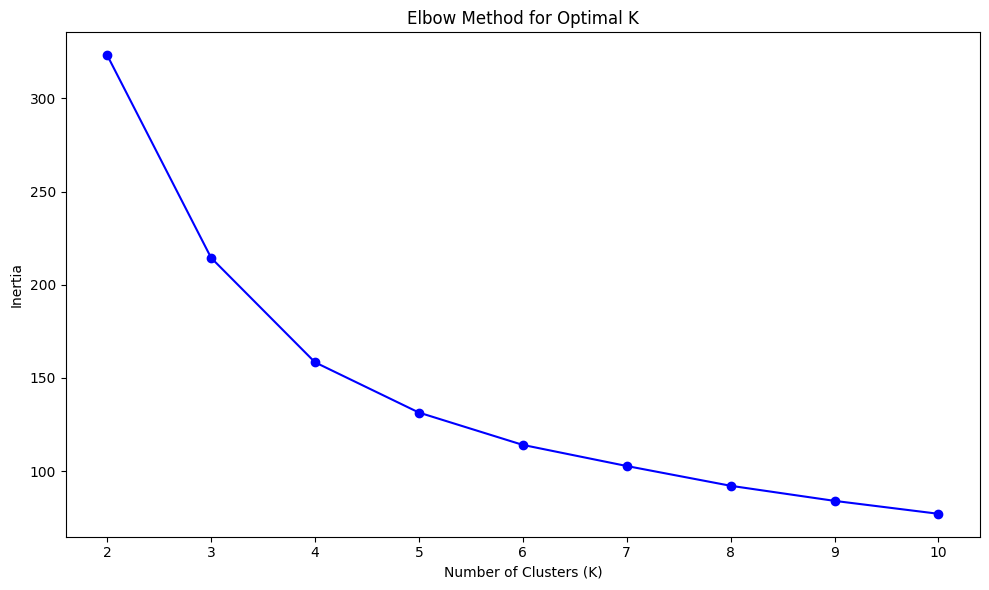

In [ ]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()

# From the chart, pick the elbow point — usually K=3 or K=4

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

# Map cluster numbers to meaningful names based on mean Monetary value
cluster_order = rfm.groupby('Segment')['Monetary'].mean().sort_values().index
segment_names = {cluster_order[0]: 'Low-Value', cluster_order[1]: 'Mid-Value', cluster_order[2]: 'High-Value'}
rfm['SegmentName'] = rfm['Segment'].map(segment_names)

print(rfm.head(10))

            Recency  Frequency  Monetary  Segment SegmentName
CustomerID                                                   
C0001           134          8     58862        0   Mid-Value
C0002            24          9     66745        1  High-Value
C0003             3          9     56553        1  High-Value
C0004            79          9     65495        1  High-Value
C0005             6         10    108413        1  High-Value
C0006           102          4     20463        2   Low-Value
C0007           147          6     46616        0   Mid-Value
C0008             7          9     68752        1  High-Value
C0009            41          8     82170        1  High-Value
C0010            37          9     52346        1  High-Value


In [7]:
segment_profiles = rfm.groupby('SegmentName').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(segment_profiles)

print("\nSegment Sizes:")
print(rfm['SegmentName'].value_counts())

             Recency  Frequency  Monetary
SegmentName                              
High-Value     42.39       9.98  76564.78
Low-Value      38.42       5.49  40396.06
Mid-Value     184.83       5.79  44631.48

Segment Sizes:
SegmentName
High-Value    88
Low-Value     69
Mid-Value     42
Name: count, dtype: int64


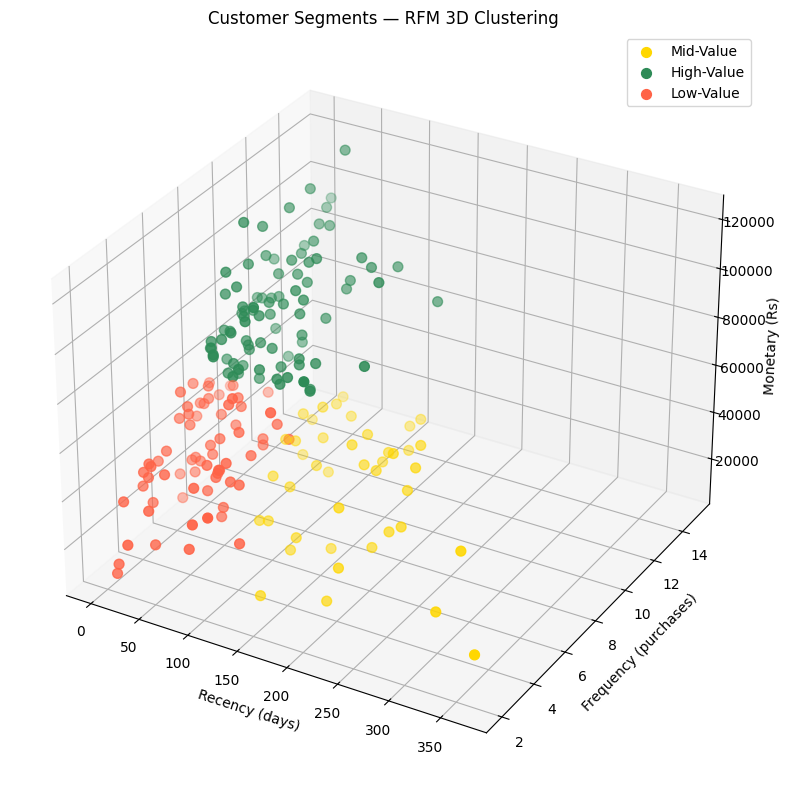

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'Low-Value': 'tomato', 'Mid-Value': 'gold', 'High-Value': 'seagreen'}

for segment in rfm['SegmentName'].unique():
    mask = rfm['SegmentName'] == segment
    ax.scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Frequency'],
        rfm[mask]['Monetary'],
        label=segment, s=50, color=colors.get(segment)
    )

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (purchases)')
ax.set_zlabel('Monetary (Rs)')
ax.set_title('Customer Segments — RFM 3D Clustering')
ax.legend()
plt.tight_layout()
plt.show()

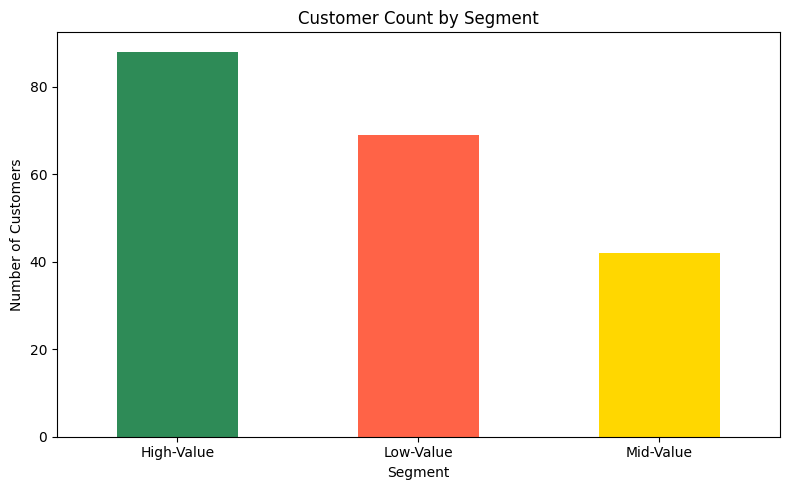

In [ ]:
rfm['SegmentName'].value_counts().plot(kind='bar', figsize=(8, 5),
    color=[colors[s] for s in rfm['SegmentName'].value_counts().index])
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
recommendations = {
    'High-Value': 'VIP treatment - exclusive offers, priority service',
    'Mid-Value': 'Growth potential - targeted campaigns, loyalty programs',
    'Low-Value': 'Win-back campaigns - special discounts, re-engagement offers'
}

for segment, rec in recommendations.items():
    print(f"{segment}: {rec}")

High-Value: VIP treatment - exclusive offers, priority service
Mid-Value: Growth potential - targeted campaigns, loyalty programs
Low-Value: Win-back campaigns - special discounts, re-engagement offers
